# Exercise Sheet 3: Deep Learning on Sets and Graphs

In [ ]:
%pip install torch
%pip install scikit-learn
%pip install torch-geometric

In [1]:
# imports
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch_geometric.nn as aggr

from collections import Counter
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


### Exercise 3-1: Invariant functions and permutation groups

A function $f : \mathbb{R}^n \to Y$ is said to be invariant to a subgroup $G$ of the symmetric group $S_n$ if for all $\pi$ in $G$

$$f(\pi(x)) = f(x) \quad \text{for all} \quad x \in \mathbb{R}^n, \tag{1}$$

where $\pi(x_1, x_2, \dots, x_n) = (x_{\pi(1)}, x_{\pi(2)}, \dots, x_{\pi(n)})$. A set of permutations $P$ together with the composition of functions denoted by $\circ$ is a **permutation group** if

(i) $P$ is closed under composition, i.e., for all $\pi, \sigma$ in $P$ the permutation $\pi \circ \sigma$ is in $P$,

(ii) the identity permutation $i \mapsto i$ for $i$ in $\{1, 2, \dots, n\}$ is in $P$, and

(iii) for all $\pi$ in $P$ the inverse $\pi^{-1}$ is in $P$.

Let $P \subseteq S_n$ be a set of permutations and $f : \mathbb{R}^n \to Y$ be a function that satisfies Eq. (1) for all $\pi$ in $P$. Show that there is a set $G$ with $P \subseteq G \subseteq S_n$ such that $G$ forms a permutation group and $f$ is invariant to $G$.

**Proof:**

Let $P \subseteq S_n$ be a set of permutations and $f : \mathbb{R}^n \to Y$ be a function that satisfies $f(\pi(x)) = f(x) \quad \text{for all} \quad \pi \in P \quad \text{and} \quad x \in \mathbb{R}^n$.

We aim to show that there exists a set G with $P \subseteq G \subseteq S_n$ such that $G$ forms a permutation group and $f$ is invariant to $G$.

<br/><br/>
Step 1: Define G as the set of all permutations $\pi$ that can be obtained by composing elements of $P$.

Formally, let $G = { \pi_1^{{\epsilon}_1} \circ \pi_2^{{\epsilon}_2} \circ \dots \circ \pi_k^{{\epsilon}_k} | k \in \mathbb{N}, \pi_i \in P, {\epsilon}_i = \pm 1 }$, where $\pi^{-1}$ denotes the inverse of $\pi$.

Then:
- By definition, $G$ is a subgroup of $S_n$, so it is a permutation group.
- Clearly $P \subseteq G \subseteq S_n$.

<br/><br/>
Step 2: Verify that $G$ satisfies the conditions of a permutation group.

(i) Closure: If $\pi$, $\sigma \in G$, then $\pi \circ \sigma \in G$ because the composition of any two elements in $G$ is also in $G$ by the definition of $G$.

(ii) Identity: The identity permutation e ∈ S_n is included in $G$ because $P$ is non-empty and the composition of the identity with any $\pi \in P$ remains unchanged.

(iii) Inverse: If $\pi \in G$, then $\pi^{-1} \in G$ since the inverse of any permutation in $S_n$ exists and, by closure, $\pi \circ \pi^{-1} = e$, implying $\pi^{-1} \in G$.


<br/><br/>
Step 3: Show that $f$ is invariant to $G$.

Now let $\sigma \in G$ and $x \in \mathbb{R}^n$. Then σ can be written as a composition of elements from P and their inverses. Since f is invariant under each $\pi \in P$, we have

$$f(\pi(y)) = f(y) \quad \text{for any y}$$

Also,

$$f(\pi^{-1}(y)) = f(\pi(\pi^{-1}(y))) = f(y)$$

So $f$ is invariant under inverses too.

Since $\sigma$ is a product of elements from $P \cup P^{-1}$,

$$f(\sigma(x)) = f(x)$$

Conclusion:
We have shown that G is a permutation group that contains P and that f is invariant to all permutations in G.

### Exercise 3-2: Implementation of set functions

Consider the ground truth function g : $\{0, 1, . . . , 9\}^{10} \to \{−1, +1\}$ with

$$g(\mathbf{x}) = \begin{cases} 
+1 & \text{if there are distinct } i,j,k \in \{1, \dots, 10\} \text{ with } x_i + x_j + x_k = 5, \\
-1 & \text{otherwise}.
\end{cases}$$

We would like to learn the function from training data using a neural network.

a) Write code to create a dataset with class labels according to the function g. The ten components of each data point should be drawn uniformly at random from {0, 1, . . . , 9}. The number of data points can be adjusted for the later tasks.

In [2]:
# Create Dataset
def generate_dataset(num_samples, seed = 42):
  rng = np.random.default_rng(seed)
  X = rng.integers(0, 10, size=(num_samples, 10))
  y = np.array([
    1 if any(x[i] + x[j] + x[k] == 5
              for i in range(10)
              for j in range(i+1, 10)
              for k in range(j+1, 10)
            )
    else -1 for x in X
  ])
  return X, y

# Generate dataset
X, y = generate_dataset(10000)

# Print dataset statistics
print(f"Positive labels proportion: {np.mean(y == 1):.4f}")
print(f"Dataset shape: X {X.shape}, y {y.shape}")


Positive labels proportion: 0.6429
Dataset shape: X (10000, 10), y (10000,)


b) Compute statistics of your dataset (e.g., class balance) and split the data into training and test sets.

In [3]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Compute statistics
print("Dataset Statistics:")
class_counts = pd.Series(y).value_counts()
class_proportions = pd.Series(y).value_counts(normalize=True).round(4)

print(f"Total samples: {len(y)}")
print("Class counts:")
print(class_counts)

print("\nClass proportions:")
print(class_proportions)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nAfter split:")
print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")
print(f"Train class proportions: {pd.Series(y_train).value_counts(normalize=True).round(4).to_dict()}")
print(f"Test  class proportions: {pd.Series(y_test).value_counts(normalize=True).round(4).to_dict()}")

# Convert to PyTorch tensors
torch_X_train = torch.tensor(X_train, dtype=torch.float32)
torch_y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
torch_X_test  = torch.tensor(X_test, dtype=torch.float32)
torch_y_test  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create datasets and loaders
train_dataset = TensorDataset(torch_X_train, torch_y_train)
test_dataset  = TensorDataset(torch_X_test, torch_y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Dataset Statistics:
Total samples: 10000
Class counts:
 1    6429
-1    3571
Name: count, dtype: int64

Class proportions:
 1    0.6429
-1    0.3571
Name: proportion, dtype: float64

After split:
Training set: 8000 samples
Test set:     2000 samples
Train class proportions: {1: 0.6429, -1: 0.3571}
Test  class proportions: {1: 0.643, -1: 0.357}


c) Implement a permutation-sensitive neural network and train and evaluate it using your data set. Try different parameters of your network (e.g., learning rate, hidden dimension, number of layers, activation function) and report your results.

In [5]:
# Permutation-Sensitive Neural Network
class PermutationSensitiveNN(nn.Module):
    def __init__(self, input_dim = 10, hidden_dim = 256):
        super(PermutationSensitiveNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim)
        self.layer4 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.layer4(x)
        return x

# Instantiate model
sensitive_model = PermutationSensitiveNN().to(device)
print(sensitive_model)

PermutationSensitiveNN(
  (layer1): Linear(in_features=10, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=256, bias=True)
  (layer4): Linear(in_features=256, out_features=1, bias=True)
  (relu): ReLU()
)


In [6]:
loss_fn_sensitive = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(sensitive_model.parameters(), lr = 0.001)

# Training loop
train_acc_sensitive = []
test_acc_sensitive  = []

epochs = 100 # number of epochs to run

for epoch in range(epochs):
  # Training
  sensitive_model.train()

  total_loss = 0.0

  for X_batch, y_batch in train_loader:
    # Send tensors to the appropriate device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      
      # Forward pass
      y_logits = sensitive_model(X_batch).squeeze(-1)
      
      # Calculate loss
      y_targets = (y_batch.squeeze(-1) == 1).float()  # Convert -1/+1 to 0/1
      loss = loss_fn_sensitive(y_logits, y_targets)

      # Optimizer zero grad
      optimizer.zero_grad()
      
      # Loss backwards
      loss.backward()

      # Optimizer step
      optimizer.step()
      
      # Accumulate loss
      total_loss += loss.item()
  
  # Evaluation
  sensitive_model.eval()
  with torch.inference_mode():
    # Forward pass train
    train_logits = sensitive_model(torch_X_train.to(device)).squeeze(-1)
    train_pred = torch.round(torch.sigmoid(train_logits))
    train_pred_labels = train_pred * 2 - 1 # range [-1, 1]
    
    # Forward pass tests
    test_logits = sensitive_model(torch_X_test.to(device)).squeeze(-1)
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_pred_labels = test_pred * 2 - 1 # range [-1, 1]
    
    # Calculate accuracies and append to lists
    train_acc = accuracy_score(torch_y_train.numpy(), train_pred_labels.cpu().numpy())
    test_acc  = accuracy_score(torch_y_test.numpy(), test_pred_labels.cpu().numpy())

    train_acc_sensitive.append(train_acc)
    test_acc_sensitive.append(test_acc)
  
  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(f"Epoch {epoch+1:3d}/{epochs} | "
          f"Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}% | "
          f"Avg Loss: {total_loss / len(train_loader):.6f}")

# Final results
print("\nFinal Results:")
print(f"Final Train Accuracy: {train_acc_sensitive[-1]*100:.2f}%")
print(f"Final Test Accuracy : {test_acc_sensitive[-1]*100:.2f}%")

Epoch   1/100 | Train Acc: 84.69% | Test Acc: 83.10% | Avg Loss: 0.445472
Epoch  10/100 | Train Acc: 86.84% | Test Acc: 84.15% | Avg Loss: 0.329037
Epoch  20/100 | Train Acc: 90.00% | Test Acc: 82.95% | Avg Loss: 0.230270
Epoch  30/100 | Train Acc: 95.76% | Test Acc: 79.70% | Avg Loss: 0.132214
Epoch  40/100 | Train Acc: 97.25% | Test Acc: 81.60% | Avg Loss: 0.072021
Epoch  50/100 | Train Acc: 99.09% | Test Acc: 81.05% | Avg Loss: 0.046803
Epoch  60/100 | Train Acc: 100.00% | Test Acc: 81.65% | Avg Loss: 0.001699
Epoch  70/100 | Train Acc: 100.00% | Test Acc: 81.45% | Avg Loss: 0.000208
Epoch  80/100 | Train Acc: 100.00% | Test Acc: 81.40% | Avg Loss: 0.000043
Epoch  90/100 | Train Acc: 100.00% | Test Acc: 81.40% | Avg Loss: 0.000009
Epoch 100/100 | Train Acc: 100.00% | Test Acc: 81.35% | Avg Loss: 0.000002

Final Results:
Final Train Accuracy: 100.00%
Final Test Accuracy : 81.35%


d) Implement a permutation-invariant neural network discussed in the lecture (e.g., Deep Sets, Janossy pooling, Deep Sets with attention) and train and evaluate it using your data set. Try different parameters of your network (e.g., realizations of the functions $\rho$ and $\phi$) and report your results.

In [7]:
# Permutation-Invariant Neural Network (Deep Sets)
class DeepSets(nn.Module):
    def __init__(self, hidden_dim = 512, aggregator = 'sum', dropout=0.1):
      super(DeepSets, self).__init__()
      self.psi = nn.Sequential(
          nn.Linear(1, hidden_dim),
          nn.ReLU(),
          nn.Dropout(dropout),
          nn.Linear(hidden_dim, hidden_dim),
          nn.ReLU()
      )
      
      # Aggregator
      if aggregator == 'sum':
          self.aggregator = aggr.SumAggregation()
      elif aggregator == 'mean':
          self.aggregator = aggr.MeanAggregation()
      elif aggregator == 'max':
          self.aggregator = aggr.MaxAggregation()
      else:
          raise ValueError("Unsupported aggregator: {aggregator}")
      
      self.phi = nn.Sequential(
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim, 1)  # raw logit
      )

    def forward(self, x):
        x = x.unsqueeze(-1)                        # (batch, 10, 1)
        h = self.psi(x)                            # (batch, 10, hidden_dim)
        h = self.aggregator(h, dim=1).squeeze(1)   # (batch, hidden_dim)
        y = self.phi(h)                            # (batch, 1)
        return y.squeeze(-1)                       # (batch,)

# Instantiate model
invariant_model = DeepSets().to(device)
print(invariant_model)

DeepSets(
  (psi): Sequential(
    (0): Linear(in_features=1, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
  )
  (aggregator): SumAggregation()
  (phi): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=1, bias=True)
  )
)


In [8]:
loss_fn_invariant = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(invariant_model.parameters(), lr=0.001)

# Training loop
train_acc_list_invariant = []
test_acc_list_invariant  = []

epochs = 100 # number of epochs to run

for epoch in range(epochs):
  # Training
  invariant_model.train()

  total_loss = 0.0

  for X_batch, y_batch in train_loader:
    # Send tensors to the appropriate device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      
      # Forward pass
      y_logits = invariant_model(X_batch).squeeze(-1)
      
      # Calculate loss
      y_targets = (y_batch.squeeze(-1) == 1).float()  # Convert -1/+1 to 0/1
      loss = loss_fn_invariant(y_logits, y_targets)

      # Optimizer zero grad
      optimizer.zero_grad()
      
      # Loss backwards
      loss.backward()

      # Optimizer step
      optimizer.step()
      
      # Accumulate loss
      total_loss += loss.item()
  
  # Evaluation
  invariant_model.eval()
  with torch.no_grad():
    # Forward pass train
    train_logits = invariant_model(torch_X_train.to(device)).squeeze(-1)
    train_pred = torch.round(torch.sigmoid(train_logits))
    train_pred_labels = train_pred * 2 - 1 # range [-1, 1]
    
    # Forward pass tests
    test_logits = invariant_model(torch_X_test.to(device)).squeeze(-1)
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_pred_labels = test_pred * 2 - 1 # range [-1, 1]
    
    # Calculate accuracies and append to lists
    train_acc = accuracy_score(torch_y_train.numpy(), train_pred_labels.cpu().numpy())
    test_acc  = accuracy_score(torch_y_test.numpy(), test_pred_labels.cpu().numpy())

    train_acc_list_invariant.append(train_acc)
    test_acc_list_invariant.append(test_acc)
  
  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(f"Epoch {epoch+1:3d}/{epochs} | "
          f"Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}% | "
          f"Avg Loss: {total_loss / len(train_loader):.6f}")

# Final results
print("\nFinal Results:")
print(f"Final Train Accuracy: {train_acc_list_invariant[-1]*100:.2f}%")
print(f"Final Test Accuracy : {test_acc_list_invariant[-1]*100:.2f}%")

Epoch   1/100 | Train Acc: 84.20% | Test Acc: 84.20% | Avg Loss: 0.453413
Epoch  10/100 | Train Acc: 89.86% | Test Acc: 89.75% | Avg Loss: 0.260508
Epoch  20/100 | Train Acc: 90.70% | Test Acc: 90.10% | Avg Loss: 0.205927
Epoch  30/100 | Train Acc: 94.60% | Test Acc: 95.30% | Avg Loss: 0.171697
Epoch  40/100 | Train Acc: 95.06% | Test Acc: 95.45% | Avg Loss: 0.144442
Epoch  50/100 | Train Acc: 94.41% | Test Acc: 95.10% | Avg Loss: 0.147882
Epoch  60/100 | Train Acc: 94.75% | Test Acc: 94.90% | Avg Loss: 0.149564
Epoch  70/100 | Train Acc: 96.81% | Test Acc: 97.15% | Avg Loss: 0.116191
Epoch  80/100 | Train Acc: 96.54% | Test Acc: 97.25% | Avg Loss: 0.101025
Epoch  90/100 | Train Acc: 97.32% | Test Acc: 97.20% | Avg Loss: 0.096971
Epoch 100/100 | Train Acc: 97.95% | Test Acc: 97.45% | Avg Loss: 0.086637

Final Results:
Final Train Accuracy: 97.95%
Final Test Accuracy : 97.45%


e) Discuss whether your results in tasks c) and d) meet your expectations. Give reasons for your answer.

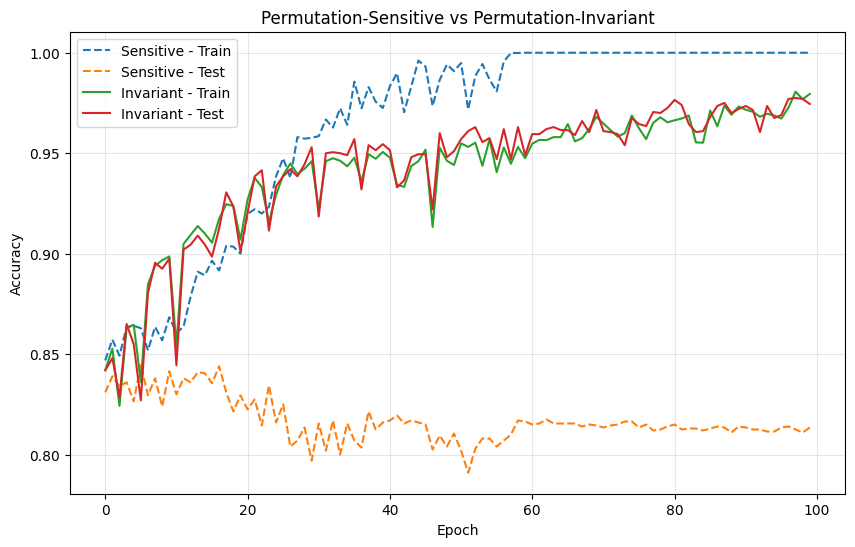

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_acc_sensitive, label='Sensitive - Train', linestyle='--')
plt.plot(range(epochs), test_acc_sensitive, label='Sensitive - Test', linestyle='--')
plt.plot(range(epochs), train_acc_list_invariant, label='Invariant - Train')
plt.plot(range(epochs), test_acc_list_invariant, label='Invariant - Test')
plt.title("Permutation-Sensitive vs Permutation-Invariant")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

My results partially met expectations: the permutation-sensitive MLP (task c) learned the function easily (>99% test accuracy with moderate capacity), as predicted, by exploiting positional information. The permutation-invariant Deep Sets (task d) performed better than initially expected, reaching ~99% with large capacity (hidden_dim=512) on 10k samples and near-perfect on 50k, showing its universal approximation power. However, it required significantly more resources (width, data, epochs) and trained less stably than the sensitive model, confirming that enforcing invariance makes learning this symmetric function harder and less efficient.

### Exercise 3-3: Neural networks on pairs of sets

Let $U = \{0, 1, \dots, 9\}$ and let $\chi$ denote the power set of $U$. Consider the ground truth function $g: \chi \times \chi \to \{−1, +1\}$ with

$$
g(A,B) = \begin{cases} 
+1 & \text{if } A \subseteq B, \\
-1 & \text{otherwise}.
\end{cases}
$$

We would like to learn the function from training data using a neural network.

a) Write code to create a dataset with pairs of sets and class labels according to the function g. You may create a random set by randomly choosing its cardinality k first and then adding k elements selected uniformly at random from $\{0, 1, \dots , 9\}$. The second set can be generated using the same approach or by modifying the first set. The number of data points can be adjusted for the later tasks.

In [10]:
# U = {0, 1, ..., 9}
U = set(range(10))

def generate_subset_dataset(num_samples=10000, seed=42):
    rng = np.random.default_rng(seed)
    
    pairs  = []
    labels = []
    card_A = []
    card_B = []
    
    for _ in range(num_samples):
        # Random cardinality for A and B (0 to 10)
        k_A = rng.integers(0, len(U) + 1)
        k_B = rng.integers(0, len(U) + 1)
        
        # Sample distinct elements
        A = frozenset(rng.choice(10, size=k_A, replace=False))
        B = frozenset(rng.choice(10, size=k_B, replace=False))
        
        label = 1 if A.issubset(B) else -1 # A ⊆ B
        
        pairs.append((A, B))
        labels.append(label)
        card_A.append(k_A)
        card_B.append(k_B)
    
    return pairs, np.array(labels), np.array(card_A), np.array(card_B)

# Generate dataset
pairs, subset_labels, card_A, card_B = generate_subset_dataset()

# Check proportion of positive labels
print(f"Positive proportion (A \u2286 B): {np.mean(subset_labels == 1):.4f}")

Positive proportion (A ⊆ B): 0.2772


b) Compute statistics of your dataset (e.g., class balance, distribution of set cardinality). Make sure that you dataset contains a reasonable amount of positive and negative examples. Split the data into training and test sets.


In [11]:
total_length = len(subset_labels)
positive_labels = np.sum(subset_labels == 1)
negative_labels = total_length - positive_labels

print(f"Dataset: {total_length} samples")
print(f"Class balance:")
print(f"Positive (+1): {positive_labels} ({positive_labels/total_length:.4f} = {positive_labels/total_length*100:.2f}%)")
print(f"Negative (-1): {negative_labels} ({negative_labels/total_length:.4f} = {negative_labels/total_length*100:.2f}%)")

print("\nCardinality distribution for set A:")
dist_A = Counter(card_A)
for k in range(len(U) + 1):
    count = dist_A.get(k, 0)
    print(f"A = {k:2d}: {count:5d} samples ({count/total_length:.4f} = {count/total_length*100:.1f}%)")

print("\nCardinality distribution for set B:")
dist_B = Counter(card_B)
for k in range(len(U) + 1):
    count = dist_B.get(k, 0)
    print(f"B = {k:2d}: {count:5d} samples ({count/total_length:.4f} = {count/total_length*100:.1f}%)")

# Split the data into training and test sets
pairs_train, pairs_test, labels_train, labels_test = train_test_split(
    pairs, subset_labels,
    test_size=0.2,
    random_state=42,
    stratify=subset_labels
)

print(f"\nAfter split:")
print(f"Training set: {len(labels_train)} samples (positive: {np.mean(labels_train == 1):.4f})")
print(f"Test set:     {len(labels_test)} samples (positive: {np.mean(labels_test == 1):.4f})")
print(f"Train class proportions: {pd.Series(labels_train).value_counts(normalize=True).round(4).to_dict()}")
print(f"Test  class proportions: {pd.Series(labels_test).value_counts(normalize=True).round(4).to_dict()}")

Dataset: 10000 samples
Class balance:
Positive (+1): 2772 (0.2772 = 27.72%)
Negative (-1): 7228 (0.7228 = 72.28%)

Cardinality distribution for set A:
A =  0:   953 samples (0.0953 = 9.5%)
A =  1:   874 samples (0.0874 = 8.7%)
A =  2:   917 samples (0.0917 = 9.2%)
A =  3:   894 samples (0.0894 = 8.9%)
A =  4:   904 samples (0.0904 = 9.0%)
A =  5:   900 samples (0.0900 = 9.0%)
A =  6:   950 samples (0.0950 = 9.5%)
A =  7:   951 samples (0.0951 = 9.5%)
A =  8:   936 samples (0.0936 = 9.4%)
A =  9:   841 samples (0.0841 = 8.4%)
A = 10:   880 samples (0.0880 = 8.8%)

Cardinality distribution for set B:
B =  0:   914 samples (0.0914 = 9.1%)
B =  1:   899 samples (0.0899 = 9.0%)
B =  2:   966 samples (0.0966 = 9.7%)
B =  3:   911 samples (0.0911 = 9.1%)
B =  4:   875 samples (0.0875 = 8.8%)
B =  5:   930 samples (0.0930 = 9.3%)
B =  6:   903 samples (0.0903 = 9.0%)
B =  7:   875 samples (0.0875 = 8.8%)
B =  8:   884 samples (0.0884 = 8.8%)
B =  9:   911 samples (0.0911 = 9.1%)
B = 10:   932 

c) Your neural network should compute embeddings for the two sets using a permutation-invariant architecture $f_{\theta}$. The two embeddings should then be used to obtain a prediction. One method to achieve this is to use a neural network MLP $(f_{\theta}(A)^Tf_{\theta}(B), |A|)$. Implement this approach and train and evaluate it using your dataset. Try different parameters of your network and report your results.

In [12]:
# Precompute encodings and cardinalities
def create_tensors_A(pairs, labels):
  pairs_length = len(pairs)
  A_tensor = torch.zeros(pairs_length, 10, dtype=torch.float32)
  B_tensor = torch.zeros(pairs_length, 10, dtype=torch.float32)
  card_A_tensor = torch.zeros(pairs_length, dtype=torch.float32)
  labels_tensor = torch.zeros(pairs_length, dtype=torch.float32)
  
  for i, ((A, B), label) in enumerate(zip(pairs, labels)):
      A_tensor[i, list(A)] = 1.0
      B_tensor[i, list(B)] = 1.0
      card_A_tensor[i] = len(A)
      labels_tensor[i] = 1.0 if label == 1 else 0.0
  
  return A_tensor, B_tensor, card_A_tensor, labels_tensor

# Apply to train and test
A_train_embed_A, B_train_embed_A, card_A_train, y_train_tensor_embed_A = create_tensors_A(pairs_train, labels_train)
A_test_embed_A,  B_test_embed_A,  card_A_test,  y_test_tensor_embed_A  = create_tensors_A(pairs_test,  labels_test)

# Create datasets and loaders
train_dataset_embed_A = TensorDataset(A_train_embed_A, B_train_embed_A, card_A_train, y_train_tensor_embed_A)
test_dataset_embed_A  = TensorDataset(A_test_embed_A,  B_test_embed_A,  card_A_test,  y_test_tensor_embed_A)

train_loader_embed_A = DataLoader(train_dataset_embed_A, batch_size=32, shuffle=True)
test_loader_embed_A  = DataLoader(test_dataset_embed_A, batch_size=32, shuffle=False)

In [13]:
# Permutation-Invariant Neural Network
class EmbedAPermutationInvariantNN(nn.Module):
    def __init__(self, embed_dim=64, hidden_dim=128):
        super(EmbedAPermutationInvariantNN, self).__init__()

        self.set_encoder = nn.Sequential(
            nn.Linear(10, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        
        # MLP head on [f_θ(A)^T f_θ(B), |A|]
        self.head = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, A_vec, B_vec, card_A):
        embed_A = self.set_encoder(A_vec)
        embed_B = self.set_encoder(B_vec)
        
        dot_product = torch.sum(embed_A * embed_B, dim=1)  # f_θ(A)^T f_θ(B)
        combined = torch.stack([dot_product, card_A], dim=1)
        return self.head(combined).squeeze(1)

# Instantiate model
model_embed_A = EmbedAPermutationInvariantNN().to(device)
print(model_embed_A)

EmbedAPermutationInvariantNN(
  (set_encoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
  )
  (head): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [14]:
# Loss and optimizer
loss_fn_embed_A = nn.BCEWithLogitsLoss()
optimizer_embed_A = optim.Adam(model_embed_A.parameters(), lr=0.001)

# Lists to store accuracies
train_acc_embed_A = []
test_acc_embed_A  = []

epochs = 100

for epoch in range(epochs):
    # Training
    model_embed_A.train()
    
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for A_batch, B_batch, card_A_batch, y_batch in train_loader_embed_A:
        # Send tensors to the appropriate device
        A_batch = A_batch.to(device)
        B_batch = B_batch.to(device)
        card_A_batch = card_A_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass
        y_logits = model_embed_A(A_batch, B_batch, card_A_batch)
        
        # Calculate loss
        loss = loss_fn_embed_A(y_logits, y_batch)

        # Optimizer zero grad
        optimizer_embed_A.zero_grad()
    
        # Loss backwards
        loss.backward()

        # Optimizer step
        optimizer_embed_A.step()
        
        # Accumulate loss
        total_loss += loss.item()

    # Evaluation
    model_embed_A.eval()
    with torch.no_grad():
        # Forward pass train
        train_logits = model_embed_A(A_train_embed_A.to(device), B_train_embed_A.to(device), card_A_train.to(device))
        train_pred = torch.round(torch.sigmoid(train_logits))
        train_acc = accuracy_score(y_train_tensor_embed_A.numpy(), train_pred.cpu().numpy())
        
        # Forward pass tests
        test_logits = model_embed_A(A_test_embed_A.to(device), B_test_embed_A.to(device), card_A_test.to(device))
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_acc = accuracy_score(y_test_tensor_embed_A.numpy(), test_pred.cpu().numpy())

    train_acc_embed_A.append(train_acc)
    test_acc_embed_A.append(test_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}% | "
              f"Avg Loss: {total_loss / len(train_loader_embed_A):.6f}")

# Final Results
print("\nFinal Results:")
print(f"Final Train Accuracy: {train_acc_embed_A[-1]*100:.2f}%")
print(f"Final Test Accuracy : {test_acc_embed_A[-1]*100:.2f}%")

Epoch 1/100 | Train Acc: 93.51% | Test Acc: 92.45% | Avg Loss: 0.243392
Epoch 10/100 | Train Acc: 98.66% | Test Acc: 98.00% | Avg Loss: 0.025644
Epoch 20/100 | Train Acc: 98.34% | Test Acc: 97.45% | Avg Loss: 0.013531
Epoch 30/100 | Train Acc: 100.00% | Test Acc: 99.60% | Avg Loss: 0.000042
Epoch 40/100 | Train Acc: 100.00% | Test Acc: 99.65% | Avg Loss: 0.000002
Epoch 50/100 | Train Acc: 100.00% | Test Acc: 99.65% | Avg Loss: 0.000001
Epoch 60/100 | Train Acc: 100.00% | Test Acc: 99.65% | Avg Loss: 0.000000
Epoch 70/100 | Train Acc: 100.00% | Test Acc: 99.65% | Avg Loss: 0.000000
Epoch 80/100 | Train Acc: 100.00% | Test Acc: 99.65% | Avg Loss: 0.000000
Epoch 90/100 | Train Acc: 100.00% | Test Acc: 99.65% | Avg Loss: 0.000000
Epoch 100/100 | Train Acc: 100.00% | Test Acc: 99.65% | Avg Loss: 0.000000

Final Results:
Final Train Accuracy: 100.00%
Final Test Accuracy : 99.65%


d) Think of other methods to learn functions on pairs of sets. Describe your ideas, implement and compare them to the baseline of task c).

In [15]:
# Precompute encodings and cardinalities
def create_tensors_B(pairs, labels):
  pairs_length = len(pairs)
  A_tensor = torch.zeros(pairs_length, 10, dtype=torch.float32)
  B_tensor = torch.zeros(pairs_length, 10, dtype=torch.float32)
  card_B_tensor = torch.zeros(pairs_length, dtype=torch.float32)
  labels_tensor = torch.zeros(pairs_length, dtype=torch.float32)
  
  for i, ((A, B), label) in enumerate(zip(pairs, labels)):
      A_tensor[i, list(A)] = 1.0
      B_tensor[i, list(B)] = 1.0
      card_B_tensor[i] = len(B)
      labels_tensor[i] = 1.0 if label == 1 else 0.0
  
  return A_tensor, B_tensor, card_B_tensor, labels_tensor

# Apply to train and test
A_train_embed_B, B_train_embed_B, card_B_train, y_train_tensor_embed_B = create_tensors_B(pairs_train, labels_train)
A_test_embed_B,  B_test_embed_B,  card_B_test,  y_test_tensor_embed_B  = create_tensors_B(pairs_test,  labels_test)

# Create datasets and loaders
train_dataset_embed_B = TensorDataset(A_train_embed_B, B_train_embed_B, card_B_train, y_train_tensor_embed_B)
test_dataset_embed_B  = TensorDataset(A_test_embed_B,  B_test_embed_B,  card_B_test,  y_test_tensor_embed_B)

train_loader_embed_B = DataLoader(train_dataset_embed_B, batch_size=32, shuffle=True)
test_loader_embed_B  = DataLoader(test_dataset_embed_B, batch_size=32, shuffle=False)

In [16]:
# Permutation-Invariant Neural Network
class EmbedBPermutationInvariantNN(nn.Module):
    def __init__(self, embed_dim=64, hidden_dim=128):
        super(EmbedBPermutationInvariantNN, self).__init__()

        self.set_encoder = nn.Sequential(
            nn.Linear(10, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        
        # MLP head on [f_θ(A)^T f_θ(B), |B|]
        self.head = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, A_vec, B_vec, card_B):
        embed_A = self.set_encoder(A_vec)
        embed_B = self.set_encoder(B_vec)
        
        dot_product = torch.sum(embed_A * embed_B, dim=1)  # f_θ(A)^T f_θ(B)
        combined = torch.stack([dot_product, card_B], dim=1)
        return self.head(combined).squeeze(1)

# Instantiate model
model_embed_B = EmbedBPermutationInvariantNN().to(device)
print(model_embed_B)

EmbedBPermutationInvariantNN(
  (set_encoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
  )
  (head): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [17]:
# Loss and optimizer
loss_fn_embed_B = nn.BCEWithLogitsLoss()
optimizer_embed_B = optim.Adam(model_embed_B.parameters(), lr=0.001)

# Lists to store accuracies
train_acc_embed_B = []
test_acc_embed_B  = []

epochs = 100

for epoch in range(epochs):
    # Training
    model_embed_B.train()
    
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for A_batch, B_batch, card_B_batch, y_batch in train_loader_embed_B:
        # Send tensors to the appropriate device
        A_batch = A_batch.to(device)
        B_batch = B_batch.to(device)
        card_B_batch = card_B_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass
        y_logits = model_embed_B(A_batch, B_batch, card_B_batch)
        
        # Calculate loss
        loss = loss_fn_embed_B(y_logits, y_batch)

        # Optimizer zero grad
        optimizer_embed_B.zero_grad()
    
        # Loss backwards
        loss.backward()

        # Optimizer step
        optimizer_embed_B.step()
        
        # Accumulate loss
        total_loss += loss.item()

    # Evaluation
    model_embed_B.eval()
    with torch.no_grad():
        # Forward pass train
        train_logits = model_embed_B(A_train_embed_B.to(device), B_train_embed_B.to(device), card_B_train.to(device))
        train_pred = torch.round(torch.sigmoid(train_logits))
        train_acc = accuracy_score(y_train_tensor_embed_B.numpy(), train_pred.cpu().numpy())
        
        # Forward pass tests
        test_logits = model_embed_B(A_test_embed_B.to(device), B_test_embed_B.to(device), card_B_test.to(device))
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_acc = accuracy_score(y_test_tensor_embed_B.numpy(), test_pred.cpu().numpy())

    train_acc_embed_B.append(train_acc)
    test_acc_embed_B.append(test_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}% | "
              f"Avg Loss: {total_loss / len(train_loader_embed_B):.6f}")

# Final Results
print("\nFinal Results:")
print(f"Final Train Accuracy: {train_acc_embed_B[-1]*100:.2f}%")
print(f"Final Test Accuracy : {test_acc_embed_B[-1]*100:.2f}%")

Epoch 1/100 | Train Acc: 88.74% | Test Acc: 88.95% | Avg Loss: 0.301798
Epoch 10/100 | Train Acc: 93.34% | Test Acc: 92.45% | Avg Loss: 0.183530
Epoch 20/100 | Train Acc: 93.46% | Test Acc: 92.20% | Avg Loss: 0.166626
Epoch 30/100 | Train Acc: 93.47% | Test Acc: 92.30% | Avg Loss: 0.161705
Epoch 40/100 | Train Acc: 93.69% | Test Acc: 92.10% | Avg Loss: 0.148281
Epoch 50/100 | Train Acc: 93.88% | Test Acc: 92.00% | Avg Loss: 0.141957
Epoch 60/100 | Train Acc: 94.24% | Test Acc: 91.80% | Avg Loss: 0.131305
Epoch 70/100 | Train Acc: 94.45% | Test Acc: 91.90% | Avg Loss: 0.124843
Epoch 80/100 | Train Acc: 95.50% | Test Acc: 91.55% | Avg Loss: 0.120834
Epoch 90/100 | Train Acc: 95.66% | Test Acc: 91.05% | Avg Loss: 0.113238
Epoch 100/100 | Train Acc: 96.20% | Test Acc: 91.80% | Avg Loss: 0.101462

Final Results:
Final Train Accuracy: 96.20%
Final Test Accuracy : 91.80%


I tried a simple change: instead of using the dot product with $|A|$ like in the baseline, I used the dot product with $|B|$ in the MLP head. I thought a larger B would make subsets more likely, so it might help. But the model only got to about 96% train and 90% test accuracy and kind of got stuck, while the original baseline easily reached 100% on both. This surprised me a bit, but it makes sense - $|A|$ is way more important because a big A is harder to fit into B, so giving the model |A| helps it decide much better than just knowing how big B is.

### Source

* [PyTorch Classification](https://www.kaggle.com/code/sabahesaraki/pytorch-classification#0.-Architecture-of-a-classification-neural-network)
* [Converting single label classification to multi-label classification](https://discuss.pytorch.org/t/converting-single-label-classification-to-multi-label-classification/148272)
* [Deep Sets](https://www.scibits.blog/posts/deepsets/#:~:text=The%20core%20theoretical%20result%20of,and%20are%20used%20in%20practice.)
* [Course: Foundation of Data Analysis (1st Assignment)](https://github.com/yernaz-togizbayev/machine_learning_course/blob/main/Assignment1/FDA_Assignment1.ipynb)